## Prophet

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting
    %pip install -q -r requirements.txt

    import os
    from google.colab import userdata
    os.environ["DAGSHUB_USER_TOKEN"] = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]      = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_API_TOKEN"]   = userdata.get("KAGGLE_API_TOKEN")

    %pip install -q kaggle
    import os; os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


Running in: Local environment


### 1. Setup and Imports

In [2]:
import os, sys, time, importlib, logging, warnings
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

# cmdstanpy's get_logger() installs its own INFO-level handler whenever the
# logger has no handlers, overriding a bare setLevel() -- the NullHandler
# stops it from doing that. Its ERROR lines are also misleading: it passes
# the chain's exit code through os.strerror(), so a plain "optimizer exited
# with code 1" (LBFGS didn't converge; Prophet retries with Newton) prints
# as "Operation not permitted". Real per-series failures are still counted
# in the fallback_series metric, so nothing useful is lost by silencing.
for _name in ("cmdstanpy", "prophet"):
    _lg = logging.getLogger(_name)
    _lg.addHandler(logging.NullHandler())
    _lg.propagate = False
    _lg.setLevel(logging.ERROR)

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root)); break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate repo root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import mlflow, mlflow.pyfunc
from mlflow.models import infer_signature
import wandb

def wandb_init_safe(**kwargs):
    """wandb.init that degrades to offline mode instead of raising.

    A W&B backend/network/permission failure should not abort an experiment
    loop after hours of compute; offline runs can be pushed later with
    `wandb sync`.
    """
    try:
        return wandb.init(**kwargs)
    except Exception as exc:
        print(f"wandb.init failed ({exc!r}); retrying in offline mode -- "
              f"upload later with `wandb sync`")
        return wandb.init(mode="offline", **kwargs)

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking

from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.arima_utils import to_arima_long
from src.prophet_utils import (
    make_holidays_df, fit_prophet_model, evaluate_prophet_config, evaluate_prophet_configs, fit_prophet_models,
)
from src.pipeline.prophet_pipeline import ProphetForecastPipeline

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()
if mlflow.active_run(): mlflow.end_run()

BLUE, PINK, PURPLE, RED, GREEN = "#7196C7", "#AE737D", "#705588", "#7E3838", "#5E9D74"
REGIME_COLORS = {"underfit": PURPLE, "balanced": BLUE, "overfit": RED}
STATUS_COLORS = {"good": GREEN, "underfit": PURPLE, "overfit": RED}

print("Setup complete.")


Accessing as lchit22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [3]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "Prophet_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY  = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

# sweep_n_series: the sweep ranks configs on a stratified subsample instead of
# all ~2,660 complete-history series. Prophet fits one cmdstan model per
# series, so a full-population sweep is 15 x 2,660 = ~40k fits -- the previous
# attempt at that scale never finished. 15 x 250 = 3,750 fits keeps the whole
# sweep in the hours-not-days range; only the single winning config is refit
# on every series at the end.
CONFIG = {
    "horizon":              26,
    "min_train_points":     52,
    "random_seed":          42,
    "sweep_n_series":       250,
    "planned_sweep_configs": 15,
}

FREQ      = "W-FRI"
MODEL_COL = "Prophet"

CONFIG


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


{'horizon': 26,
 'min_train_points': 52,
 'random_seed': 42,
 'sweep_n_series': 250,
 'planned_sweep_configs': 15}

### 3. Load Data

In [4]:
train_df, test_df = load_merged()
print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")
CONFIG["horizon"] = test_df["Date"].nunique()
train_df.head()


train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [5]:
train_prepared = apply_shared_features(train_df)
print(f"Columns: {train_prepared.shape[1]}")
train_prepared.head()


Columns: 23


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Feature Selection

In [6]:
PROPHET_FEATURE_DECISION = {
    "feature_set": "target_history_plus_holidays",
    "uses_exogenous_features": False,
    "used_model_columns": "ds, y, holidays",
    "reason": (
        "Prophet is a univariate Bayesian structural time series model. "
        "It models each Store-Dept series independently using its own "
        "sales history. The four Walmart competition holidays (Super Bowl, "
        "Labor Day, Thanksgiving, Christmas) are passed natively via "
        "Prophet's holidays argument, giving explicit holiday effects "
        "without needing exogenous regressor columns."
    ),
}

print("Holidays passed to Prophet:")
display(make_holidays_df())
PROPHET_FEATURE_DECISION


Holidays passed to Prophet:


,holiday,ds
0,Super_Bowl,2010-02-12
1,Super_Bowl,2011-02-11
2,Super_Bowl,2012-02-10
3,Super_Bowl,2013-02-08
4,Labor_Day,2010-09-10
5,Labor_Day,2011-09-09
6,Labor_Day,2012-09-07
7,Labor_Day,2013-09-06
8,Thanksgiving,2010-11-26
9,Thanksgiving,2011-11-25


{'feature_set': 'target_history_plus_holidays',
 'uses_exogenous_features': False,
 'used_model_columns': 'ds, y, holidays',
 'reason': "Prophet is a univariate Bayesian structural time series model. It models each Store-Dept series independently using its own sales history. The four Walmart competition holidays (Super Bowl, Labor Day, Thanksgiving, Christmas) are passed natively via Prophet's holidays argument, giving explicit holiday effects without needing exogenous regressor columns."}

### 6. Time-Series and Window Setup

In [7]:
train_part, valid_part = time_based_split(train_prepared, valid_weeks=CONFIG["horizon"])

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")

long_df    = to_arima_long(train_prepared)
train_long = to_arima_long(train_part)
valid_long = to_arima_long(valid_part)

series_lengths = long_df.groupby("unique_id").size()
train_lengths  = train_long.groupby("unique_id").size()
valid_lengths  = valid_long.groupby("unique_id").size()

PROPHET_SERIES_LENGTH = int(series_lengths.max())
prophet_ids = series_lengths[series_lengths == PROPHET_SERIES_LENGTH].index
prophet_ids = prophet_ids.intersection(train_lengths[train_lengths >= CONFIG["min_train_points"]].index)
prophet_ids = prophet_ids.intersection(valid_lengths[valid_lengths == CONFIG["horizon"]].index)

print(f"Complete-history series: {len(prophet_ids):,}")
print(f"Dropped short/ragged series: {long_df['unique_id'].nunique() - len(prophet_ids)}")

# Stratified sweep subsample: rank complete-history series by mean weekly
# sales, split into quartiles, sample proportionally from each -- keeps the
# high-revenue series (which dominate WMAE) represented instead of a purely
# random draw.
mean_sales = (
    train_long[train_long["unique_id"].isin(prophet_ids)]
    .groupby("unique_id")["y"].mean()
)
quartile = pd.qcut(mean_sales, 4, labels=False)
per_stratum = CONFIG["sweep_n_series"] // 4
sweep_ids = pd.Index(
    mean_sales.groupby(quartile, group_keys=False)
    .apply(lambda s: s.sample(min(per_stratum, len(s)), random_state=CONFIG["random_seed"]))
    .index
)
print(f"Sweep subsample: {len(sweep_ids)} series ({per_stratum} per sales quartile)")

holiday_lookup = train_prepared.assign(
    unique_id=train_prepared["Store"].astype(str) + "_" + train_prepared["Dept"].astype(str),
    ds=train_prepared["Date"],
)[["unique_id", "ds", "IsHoliday"]].drop_duplicates()
holiday_lookup["IsHoliday"] = holiday_lookup["IsHoliday"].fillna(False).astype(bool)

train_by_id = {
    uid: grp.sort_values("ds").set_index("ds")["y"].astype(float).asfreq(FREQ)
    for uid, grp in train_long.groupby("unique_id")
    if uid in sweep_ids
}
valid_by_id = {
    uid: grp.sort_values("ds")[["unique_id", "ds", "y"]].copy()
    for uid, grp in valid_long.groupby("unique_id")
    if uid in sweep_ids
}

def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0: return float("nan")
    return ((val_wmae - train_wmae) / train_wmae) * 100

def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap): return "unknown"
    return "overfit" if gap > 25 else "underfit" if gap < -10 else "good"

print("Prepared grouped Prophet inputs for the sweep subsample.")


Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26
Complete-history series: 2,660
Dropped short/ragged series: 671
Sweep subsample: 248 series (62 per sales quartile)
Prepared grouped Prophet inputs for the sweep subsample.


### 7. Sanity Check and Runtime Projection

In [8]:
sanity_config = {
    "label":  "sanity_prophet",
    "regime": "sanity",
    "changepoint_prior_scale": 0.05,
    "seasonality_mode": "additive",
    "yearly_seasonality": 10,
    "weekly_seasonality": False,
    "daily_seasonality": False,
}

# Time 12 series through the real evaluation path (fit + validation predict +
# insample predict) single-threaded, then project the full sweep's wall time
# BEFORE committing to it. If the projection is over budget, lower
# CONFIG["sweep_n_series"] in section 2 and rerun from section 6.
timing_ids = list(sweep_ids)[:12]
t0 = time.perf_counter()
sanity_cv, sanity_val_wmae, sanity_failures, _ = evaluate_prophet_config(
    config=sanity_config,
    prophet_ids=timing_ids,
    train_by_id=train_by_id,
    valid_by_id=valid_by_id,
    holiday_lookup=holiday_lookup,
    model_col=MODEL_COL,
    min_train_points=CONFIG["min_train_points"],
    n_jobs=1,
)
elapsed = time.perf_counter() - t0

assert sanity_failures == 0, f"{sanity_failures} sanity fits failed"
assert np.isfinite(sanity_val_wmae)

per_fit = elapsed / len(timing_ids)
workers = os.cpu_count()
sweep_fits = CONFIG["planned_sweep_configs"] * len(sweep_ids)
final_fits = len(prophet_ids)
sweep_min = sweep_fits * per_fit / workers / 60
final_min = final_fits * per_fit / workers / 60

print(f"Sanity check passed  (val WMAE on {len(timing_ids)} series: {sanity_val_wmae:,.2f})")
print(f"Measured: {per_fit:.2f}s per series fit (single-threaded)")
print(f"Projected sweep:     {CONFIG['planned_sweep_configs']} configs x {len(sweep_ids)} series "
      f"= {sweep_fits:,} fits  ~ {sweep_min:,.0f} min on {workers} threads")
print(f"Projected final fit: {final_fits:,} series ~ {final_min:,.0f} min (upper bound; skips both predicts)")


/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Evaluating 1 config(s) x 12 series (12 fits total, n_jobs=1, threading)
Sanity check passed  (val WMAE on 12 series: 513.78)
Measured: 0.04s per series fit (single-threaded)
Projected sweep:     15 configs x 248 series = 3,720 fits  ~ 0 min on 10 threads
Projected final fit: 2,660 series ~ 0 min (upper bound; skips both predicts)


[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:    0.3s finished


### 8. Baseline Run

In [9]:
baseline_config = {
    "label":  "baseline_prophet",
    "regime": "baseline",
    "changepoint_prior_scale": 0.05,
    "seasonality_prior_scale": 10.0,
    "holidays_prior_scale":    10.0,
    "seasonality_mode":        "additive",
    "yearly_seasonality":      10,
    "weekly_seasonality":      False,
    "daily_seasonality":       False,
    "changepoint_range":       0.8,
}

with mlflow.start_run(run_name="Prophet_Baseline") as run:
    try:
        wandb_init_safe(
            entity=WANDB_ENTITY, project=WANDB_PROJECT,
            name="Prophet_Baseline", group="Prophet", job_type="baseline",
            tags=["Prophet", "baseline", "target_history_plus_holidays"],
            config={**CONFIG, **baseline_config, **PROPHET_FEATURE_DECISION},
            reinit="finish_previous",
        )
        cv_df, val_wmae, failures, train_wmae = evaluate_prophet_config(
            config=baseline_config,
            prophet_ids=sweep_ids,
            train_by_id=train_by_id,
            valid_by_id=valid_by_id,
            holiday_lookup=holiday_lookup,
            model_col=MODEL_COL,
            min_train_points=CONFIG["min_train_points"],
        )
        gap    = fit_gap_pct(train_wmae, val_wmae)
        status = classify_fit_status(train_wmae, val_wmae)

        mlflow.log_params({k: v for k, v in baseline_config.items() if k not in ("label", "regime")})
        mlflow.log_params({"model": "Prophet", "feature_set": PROPHET_FEATURE_DECISION["feature_set"],
                           "n_series_evaluated": len(sweep_ids),
                           "gradient_logging_applicable": False})
        mlflow.log_metrics({"train_wmae": train_wmae, "val_wmae": val_wmae,
                            "gap_pct": gap, "fallback_series": failures})
        wandb.log({"train_wmae": train_wmae, "val_wmae": val_wmae,
                   "gap_pct": gap, "status": status, "fallback_series": failures})

        print(f"Baseline train WMAE: {train_wmae:,.2f}")
        print(f"Baseline val   WMAE: {val_wmae:,.2f}")
        print(f"Gap: {gap:.1f}%  Status: {status}  Fallbacks: {failures}")
    finally:
        wandb.finish()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/macbookpro/.netrc.
wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Evaluating 1 config(s) x 248 series (248 fits total, n_jobs=-1, threading)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 248 out of 248 | elapsed:    5.6s finished


Baseline train WMAE: 1,205.09
Baseline val   WMAE: 1,989.86
Gap: 65.1%  Status: overfit  Fallbacks: 0


fallback_series,▁
gap_pct,▁
train_wmae,▁
val_wmae,▁
fallback_series,0
gap_pct,65.12118
status,overfit
train_wmae,1205.09372
val_wmae,1989.86499


2026/07/16 03:40:23 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_Baseline at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/02f9b884de4f4e13b6f117e4f049712d.
2026/07/16 03:40:23 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


### 9. Hyperparameters

In [10]:
param_grid = [
    {"changepoint_prior_scale": 0.001, "seasonality_prior_scale": 0.1,   "holidays_prior_scale": 1.0,   "seasonality_mode": "additive",       "yearly_seasonality": 5,  "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "underfit_1", "regime": "underfit"},
    {"changepoint_prior_scale": 0.005, "seasonality_prior_scale": 0.5,   "holidays_prior_scale": 0.5,   "seasonality_mode": "additive",       "yearly_seasonality": 3,  "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.60, "label": "underfit_2", "regime": "underfit"},
    {"changepoint_prior_scale": 0.001, "seasonality_prior_scale": 0.1,   "holidays_prior_scale": 0.1,   "seasonality_mode": "multiplicative", "yearly_seasonality": 5,  "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "underfit_3", "regime": "underfit"},

    {"changepoint_prior_scale": 0.05,  "seasonality_prior_scale": 10.0,  "holidays_prior_scale": 10.0,  "seasonality_mode": "additive",       "yearly_seasonality": 10, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "balanced_1", "regime": "balanced"},
    {"changepoint_prior_scale": 0.05,  "seasonality_prior_scale": 10.0,  "holidays_prior_scale": 1.0,   "seasonality_mode": "additive",       "yearly_seasonality": 20, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "balanced_2", "regime": "balanced"},
    {"changepoint_prior_scale": 0.05,  "seasonality_prior_scale": 10.0,  "holidays_prior_scale": 1.0,   "seasonality_mode": "multiplicative", "yearly_seasonality": 20, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "balanced_3", "regime": "balanced"},
    {"changepoint_prior_scale": 0.10,  "seasonality_prior_scale": 10.0,  "holidays_prior_scale": 10.0,  "seasonality_mode": "additive",       "yearly_seasonality": 20, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "balanced_4", "regime": "balanced"},
    {"changepoint_prior_scale": 0.10,  "seasonality_prior_scale": 5.0,   "holidays_prior_scale": 5.0,   "seasonality_mode": "additive",       "yearly_seasonality": 10, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.90, "label": "balanced_5", "regime": "balanced"},
    {"changepoint_prior_scale": 0.10,  "seasonality_prior_scale": 5.0,   "holidays_prior_scale": 5.0,   "seasonality_mode": "multiplicative", "yearly_seasonality": 10, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.90, "label": "balanced_6", "regime": "balanced"},
    {"changepoint_prior_scale": 0.03,  "seasonality_prior_scale": 15.0,  "holidays_prior_scale": 15.0,  "seasonality_mode": "additive",       "yearly_seasonality": 15, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.85, "label": "balanced_7", "regime": "balanced"},
    {"changepoint_prior_scale": 0.05,  "seasonality_prior_scale": 20.0,  "holidays_prior_scale": 20.0,  "seasonality_mode": "additive",       "yearly_seasonality": 10, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.80, "label": "balanced_8", "regime": "balanced"},
    {"changepoint_prior_scale": 0.20,  "seasonality_prior_scale": 10.0,  "holidays_prior_scale": 10.0,  "seasonality_mode": "additive",       "yearly_seasonality": 20, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.90, "label": "balanced_9", "regime": "balanced"},

    {"changepoint_prior_scale": 0.50,  "seasonality_prior_scale": 100.0, "holidays_prior_scale": 100.0, "seasonality_mode": "additive",       "yearly_seasonality": 25, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.95, "label": "overfit_1", "regime": "overfit"},
    {"changepoint_prior_scale": 0.50,  "seasonality_prior_scale": 100.0, "holidays_prior_scale": 100.0, "seasonality_mode": "multiplicative", "yearly_seasonality": 25, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.95, "label": "overfit_2", "regime": "overfit"},
    {"changepoint_prior_scale": 1.00,  "seasonality_prior_scale": 200.0, "holidays_prior_scale": 200.0, "seasonality_mode": "additive",       "yearly_seasonality": 30, "weekly_seasonality": False, "daily_seasonality": False, "changepoint_range": 0.98, "label": "overfit_3", "regime": "overfit"},
]

assert len(param_grid) == CONFIG["planned_sweep_configs"]
print(f"Total configs: {len(param_grid)}")
regime_counts = {r: sum(1 for c in param_grid if c['regime'] == r) for r in ['underfit', 'balanced', 'overfit']}
print("By regime:", regime_counts)


Total configs: 15
By regime: {'underfit': 3, 'balanced': 9, 'overfit': 3}


### 10. Prophet Experiments

In [11]:
results     = {}
cv_by_label = {}

best_val_wmae = float("inf")
best_run_id   = None
best_label    = None

# Single shared thread pool across all configs x series, instead of one pool
# per config, so no worker sits idle waiting on a config's slowest straggler.
t0 = time.perf_counter()
sweep_results = evaluate_prophet_configs(
    configs=param_grid,
    prophet_ids=sweep_ids,
    train_by_id=train_by_id,
    valid_by_id=valid_by_id,
    holiday_lookup=holiday_lookup,
    model_col=MODEL_COL,
    min_train_points=CONFIG["min_train_points"],
)
print(f"Sweep compute finished in {(time.perf_counter() - t0) / 60:,.1f} min")

with mlflow.start_run(run_name="Prophet_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs",          len(param_grid))
    mlflow.log_param("model",              "Prophet")
    mlflow.log_param("feature_set",        PROPHET_FEATURE_DECISION["feature_set"])
    mlflow.log_param("n_series_evaluated", len(sweep_ids))
    mlflow.log_param("sweep_sampling",     "stratified_by_mean_sales_quartile")
    mlflow.log_param("gradient_logging_applicable", False)

    for config in param_grid:
        label  = config["label"]
        regime = config["regime"]

        with mlflow.start_run(run_name=f"Prophet_{label}", nested=True) as nested_run:
            try:
                wandb_init_safe(
                    entity=WANDB_ENTITY, project=WANDB_PROJECT,
                    name=f"Prophet_{label}", group="Prophet", job_type="hyperparam_sweep",
                    tags=["Prophet", regime],
                    config={**CONFIG, **config},
                    reinit="finish_previous",
                )
                summary    = sweep_results[label]
                cv_df      = summary["cv_df"]
                val_wmae   = summary["val_wmae"]
                failures   = summary["failures"]
                train_wmae = summary["train_wmae"]
                gap    = fit_gap_pct(train_wmae, val_wmae)
                status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({k: v for k, v in config.items() if k not in ("label", "regime")})
                mlflow.log_params({"label": label, "regime": regime,
                                   "feature_set": PROPHET_FEATURE_DECISION["feature_set"],
                                   "n_series_evaluated": len(sweep_ids)})
                mlflow.log_metrics({"train_wmae": train_wmae, "val_wmae": val_wmae,
                                    "gap_pct": gap, "fallback_series": failures})
                wandb.log({"train_wmae": train_wmae, "val_wmae": val_wmae,
                           "gap_pct": gap, "status": status})

                cv_by_label[label] = cv_df
                results[label] = {
                    "label": label, "regime": regime, "status": status,
                    "feature_set": PROPHET_FEATURE_DECISION["feature_set"],
                    **{k: v for k, v in config.items() if k not in ("label", "regime")},
                    "train_wmae": train_wmae, "val_wmae": val_wmae,
                    "gap_pct": gap, "fallback_series": failures,
                    "run_id": nested_run.info.run_id,
                }

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id   = nested_run.info.run_id
                    best_label    = label

                print(f"{label:<12} train={train_wmae:,.0f}  val={val_wmae:,.0f}  gap={gap:+.1f}%  {status}")

            except Exception as exc:
                print(f"{label} FAILED: {exc}")
                mlflow.log_param("error", str(exc))
            finally:
                wandb.finish()


Evaluating 15 config(s) x 248 series (3,720 fits total, n_jobs=-1, threading)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   36.1s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:   51.4s
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 3720 out of 3720 | elapsed:  1.7min finished


Sweep compute finished in 1.7 min


underfit_1   train=1,928  val=3,064  gap=+58.9%  overfit


gap_pct,▁
train_wmae,▁
val_wmae,▁
gap_pct,58.9181
status,overfit
train_wmae,1927.97779
val_wmae,3063.90575


...

gap_pct,▁
train_wmae,▁
val_wmae,▁
gap_pct,576.77876
status,overfit
train_wmae,636.4767
val_wmae,4307.53906


2026/07/16 03:44:10 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_overfit_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/29a0cf9813674e0cbdf301dc9817de0e.
2026/07/16 03:44:10 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


overfit_3    train=549  val=7,433  gap=+1254.5%  overfit


gap_pct,▁
train_wmae,▁
val_wmae,▁
gap_pct,1254.52346
status,overfit
train_wmae,548.73732
val_wmae,7432.77567


2026/07/16 03:44:17 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_overfit_3 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/36d3e6473282449088d2d003a8452b3d.
2026/07/16 03:44:17 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.
2026/07/16 03:44:19 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_HyperparamSweep at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/4b380ab6f015441e8d23ac79c6a53fb3.
2026/07/16 03:44:19 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


### 11. Results

In [12]:
results_df = pd.DataFrame(results.values()).sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label", "regime", "status",
    "changepoint_prior_scale", "seasonality_prior_scale", "holidays_prior_scale",
    "seasonality_mode", "yearly_seasonality", "changepoint_range",
    "feature_set", "train_wmae", "val_wmae", "gap_pct", "fallback_series",
]
display(results_df[display_cols])

os.makedirs("reports", exist_ok=True)
results_path = "reports/prophet_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)
    mlflow.log_metric("best_val_wmae", best_val_wmae)

print(f"\nBest: {best_label}  val_wmae={best_val_wmae:,.2f}")


,label,regime,status,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,seasonality_mode,yearly_seasonality,changepoint_range,feature_set,train_wmae,val_wmae,gap_pct,fallback_series
0,balanced_8,balanced,overfit,0.050,20.0,20.0,additive,10,0.80,target_history_plus_holidays,1205.464714,1982.723460,64.477934,0
1,balanced_6,balanced,overfit,0.100,5.0,5.0,multiplicative,10,0.90,target_history_plus_holidays,1191.913471,1983.604146,66.421825,0
2,balanced_7,balanced,overfit,0.030,15.0,15.0,additive,15,0.85,target_history_plus_holidays,1018.392041,1986.215543,95.034472,0
3,balanced_1,balanced,overfit,0.050,10.0,10.0,additive,10,0.80,target_history_plus_holidays,1205.093725,1989.864990,65.121181,0
4,balanced_5,balanced,overfit,0.100,5.0,5.0,additive,10,0.90,target_history_plus_holidays,1191.857902,2031.131313,70.417238,0
5,balanced_2,balanced,overfit,0.050,10.0,1.0,additive,20,0.80,target_history_plus_holidays,857.085750,2054.892412,139.753422,0
6,balanced_3,balanced,overfit,0.050,10.0,1.0,multiplicative,20,0.80,target_history_plus_holidays,837.289348,2059.678381,145.993621,0
7,balanced_4,balanced,overfit,0.100,10.0,10.0,additive,20,0.80,target_history_plus_holidays,839.701065,2263.482965,169.558187,0
8,balanced_9,balanced,overfit,0.200,10.0,10.0,additive,20,0.90,target_history_plus_holidays,822.348450,2884.945589,250.817903,0
9,underfit_3,underfit,good,0.001,0.1,0.1,multiplicative,5,0.80,target_history_plus_holidays,2455.720872,2945.748261,19.954523,0


2026/07/16 14:25:46 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_balanced_8 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/355a13100df2483bba61577d395efcd2.
2026/07/16 14:25:46 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.



Best: balanced_8  val_wmae=1,982.72


### 12. Plots

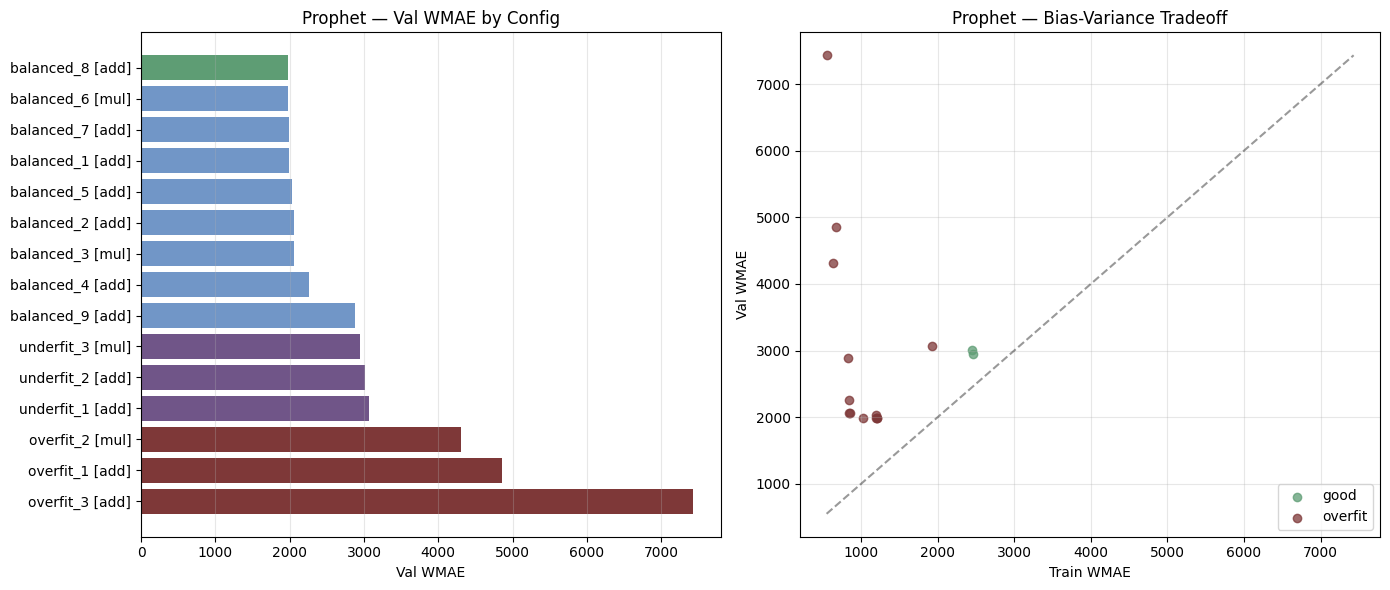

2026/07/16 14:25:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_balanced_8 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/355a13100df2483bba61577d395efcd2.
2026/07/16 14:25:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


In [13]:
os.makedirs("Plots", exist_ok=True)

top_runs = results_df.sort_values("val_wmae").copy()
colors = [GREEN if l == best_label else REGIME_COLORS.get(r, BLUE)
          for l, r in zip(top_runs["label"], top_runs["regime"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_runs["label"] + " [" + top_runs["seasonality_mode"].str[:3] + "]",
             top_runs["val_wmae"], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel("Val WMAE")
axes[0].set_title("Prophet — Val WMAE by Config")
axes[0].grid(axis="x", alpha=0.3)

for status, sdf in results_df.groupby("status"):
    axes[1].scatter(sdf["train_wmae"], sdf["val_wmae"],
                    c=STATUS_COLORS.get(status, BLUE), alpha=0.75, label=status)
lo = float(results_df[["train_wmae","val_wmae"]].min().min())
hi = float(results_df[["train_wmae","val_wmae"]].max().max())
axes[1].plot([lo, hi], [lo, hi], "k--", alpha=0.4)
axes[1].set_xlabel("Train WMAE"); axes[1].set_ylabel("Val WMAE")
axes[1].set_title("Prophet — Bias-Variance Tradeoff")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = "Plots/prophet_sweep.png"
plt.savefig(plot_path, dpi=200); plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)


### 13. Error Analysis

In [14]:
best_cv_df = cv_by_label[best_label].copy()
best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df[MODEL_COL]).abs()
best_cv_df[["Store", "Dept"]] = best_cv_df["unique_id"].str.split("_", n=1, expand=True)

worst_store_dept = (
    best_cv_df.groupby(["Store", "Dept"])["abs_error"]
    .mean().sort_values(ascending=False).head(15)
)
display(worst_store_dept)

holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae",    float(holiday_error.get(True,  np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))


Store  Dept
34     65      19305.043098
14     95      15426.161716
31     90      15404.805445
4      72      13399.513810
13     5        9909.436319
19     72       8195.527880
27     5        7216.220468
14     93       7045.407074
18     92       6958.196317
35     11       6909.754313
23     9        6836.790176
13     3        6687.893680
4      7        6542.947157
18     40       6451.508682
6      9        6221.850683
Name: abs_error, dtype: float64

IsHoliday
False    1934.304364
True     2161.874114
Name: abs_error, dtype: float64

2026/07/16 14:25:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_balanced_8 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/355a13100df2483bba61577d395efcd2.
2026/07/16 14:25:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


### 14. Error Plots

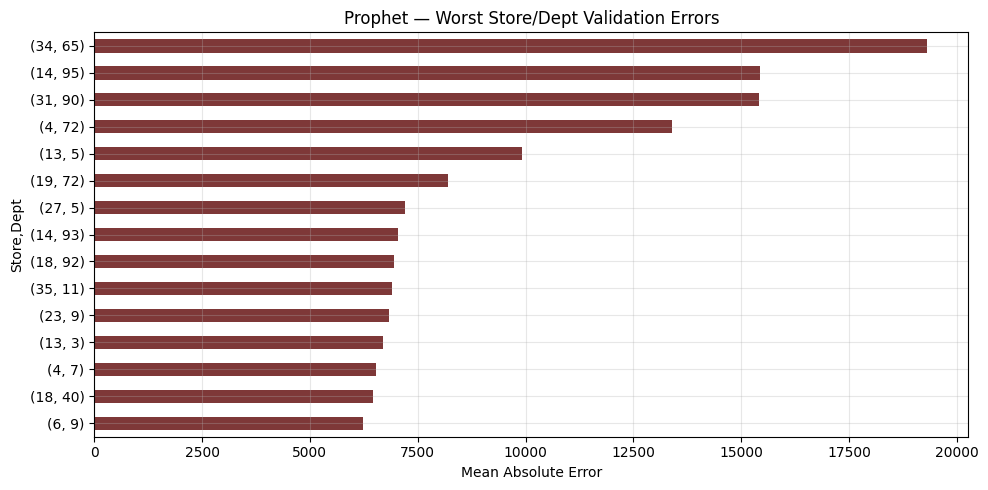

2026/07/16 14:25:54 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_balanced_8 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/355a13100df2483bba61577d395efcd2.
2026/07/16 14:25:54 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
worst_store_dept.sort_values().plot(kind="barh", ax=ax, color=RED)
ax.set_xlabel("Mean Absolute Error")
ax.set_title("Prophet — Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)
plt.tight_layout()
error_plot_path = "Plots/prophet_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200); plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)


### 15. Best Model

In [16]:
print("Best label:",           best_label)
print("Best run id:",          best_run_id)
print("Best validation WMAE:", best_val_wmae)

assert best_label  is not None
assert best_run_id is not None

best_config = next(c for c in param_grid if c["label"] == best_label)
print("Best config:"); display(best_config)

full_long_df    = to_arima_long(train_prepared)
fallback_by_id  = (full_long_df.sort_values("ds")
                   .groupby("unique_id")["y"].last().astype(float).to_dict())
global_fallback = float(full_long_df["y"].median())

with mlflow.start_run(run_name="Prophet_FinalModel") as final_run:
    try:
        wandb_init_safe(
            entity=WANDB_ENTITY, project=WANDB_PROJECT,
            name="Prophet_FinalModel", group="Prophet", job_type="final_training",
            tags=["Prophet", "final"],
            config={**CONFIG, **best_config, "best_val_wmae": best_val_wmae},
            reinit="finish_previous",
        )
        t0 = time.perf_counter()
        final_models, final_failures = fit_prophet_models(
            full_long_df=full_long_df, ids=prophet_ids, config=best_config,
        )
        print(f"Fit {len(final_models):,} final Prophet models "
              f"({len(final_failures)} failures) in {(time.perf_counter() - t0) / 60:,.1f} min")

        os.makedirs("artifacts", exist_ok=True)
        prophet_model_path = "artifacts/prophet_models.joblib"
        joblib.dump({
            "models":          final_models,
            "fallback_by_id":  fallback_by_id,
            "global_fallback": global_fallback,
        }, prophet_model_path)

        pipeline = ProphetForecastPipeline(
            fallback_by_id=fallback_by_id, global_fallback=global_fallback,
        )
        pipeline.models = final_models

        sample_input  = test_df.head(5)
        sample_output = pipeline.predict(None, sample_input)
        signature     = infer_signature(sample_input, sample_output)

        mlflow.log_params({k: v for k, v in best_config.items() if k not in ("label", "regime")})
        mlflow.log_params({"best_label": best_label, "feature_set": PROPHET_FEATURE_DECISION["feature_set"],
                           "final_failures": len(final_failures)})
        mlflow.log_metric("best_val_wmae",  best_val_wmae)
        mlflow.log_metric("n_final_models", len(final_models))

        model_uri = mlflow.pyfunc.log_model(
            artifact_path="prophet_model",
            python_model=pipeline,
            artifacts={"prophet_model_path": prophet_model_path},
            signature=signature,
            registered_model_name="Prophet_WalmartForecast",
        ).model_uri

        wandb.log({"best_val_wmae": best_val_wmae, "n_final_models": len(final_models)})
        print(f"Model registered. URI: {model_uri}")
    finally:
        wandb.finish()


Best label: balanced_8
Best run id: 355a13100df2483bba61577d395efcd2
Best validation WMAE: 1982.7234599704968
Best config:


{'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 20.0,
 'holidays_prior_scale': 20.0,
 'seasonality_mode': 'additive',
 'yearly_seasonality': 10,
 'weekly_seasonality': False,
 'daily_seasonality': False,
 'changepoint_range': 0.8,
 'label': 'balanced_8',
 'regime': 'balanced'}

Fitting 2,660 final Prophet models (n_jobs=-1, threading)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:   26.4s
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:   36.7s
[Parallel(n_jobs=-1)]: Done 2660 out of 2660 | elapsed:   40.1s finished


Fit 2,660 final Prophet models (0 failures) in 0.7 min


Successfully registered model 'Prophet_WalmartForecast'.
2026/07/16 14:30:38 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Prophet_WalmartForecast, version 1


Model registered. URI: runs:/a47294847be74178a411c243b2e8f978/prophet_model


Created version '1' of model 'Prophet_WalmartForecast'.


best_val_wmae,▁
n_final_models,▁
best_val_wmae,1982.72346
n_final_models,2660


2026/07/16 14:30:40 INFO mlflow.tracking._tracking_service.client: 🏃 View run Prophet_FinalModel at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8/runs/a47294847be74178a411c243b2e8f978.
2026/07/16 14:30:40 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/8.


### 16. Test Loading

In [17]:
loaded_model = mlflow.pyfunc.load_model(model_uri)
loaded_preds = loaded_model.predict(test_df.head(200))

display(loaded_preds.head())
print("Loaded prediction shape:", loaded_preds.shape)
assert set(loaded_preds.columns) == {"Id", "Weekly_Sales"}
assert loaded_preds["Weekly_Sales"].notna().all()


,Id,Weekly_Sales
0,1_1_2012-11-02,33259.687981
1,1_1_2012-11-09,27773.169710
2,1_1_2012-11-16,18967.350824
3,1_1_2012-11-23,19617.588759
4,1_1_2012-11-30,19685.445387


Loaded prediction shape: (200, 2)
